# 퍼널 분석 EDA

**데이터**: `funnel_df.csv` (전처리 완료, 99,441건)
**대상**: `is_valid_funnel == True` (95,088건 — 4단계 timestamp 모두 존재 + 음수 duration 없음)

**핵심 질문**: 주문 완료 → 결제 승인 → 물류 인도 → 배송 완료 중 **어느 구간이 가장 오래 걸리는가?**

**EDA 순서**
1. 단계별 소요시간 분포 (히스토그램 + KDE)
2. 단계별 비교 (박스플롯)
3. 전체 리드타임 + 약속 vs 실제 지연 분포
4. 지연 주문 vs 정상 주문 — 어느 단계에서 차이가 나나
5. 지역(state)별 단계 시간 — 허브 위치 후보 발굴
6. 월별 추이 — 개선/악화 트렌드

In [8]:
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─── 시각화 스타일 통일 ──────────────────────────────────────────────────────
# ⚠ 순서 중요: seaborn 테마 먼저 → 그 다음 한글 폰트
#   (sns.set_theme 가 font.family 를 덮어쓰기 때문)
sns.set_theme(style="whitegrid", palette="Set2")

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlepad": 12,
    "grid.alpha": 0.3,
})

# 한글 폰트 — sans-serif 폴백 리스트에 한글 폰트를 1순위로 박아넣어야 안전
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
    plt.rcParams["font.sans-serif"] = ["Malgun Gothic", "DejaVu Sans"]
elif platform.system() == "Darwin":   # macOS
    plt.rcParams["font.family"] = "AppleGothic"
    plt.rcParams["font.sans-serif"] = ["AppleGothic", "DejaVu Sans"]
else:                                  # Linux
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["font.sans-serif"] = ["NanumGothic", "DejaVu Sans"]

plt.rcParams["axes.unicode_minus"] = False  # 음수 부호 깨짐 방지

# 단계 라벨/색상 — 모든 EDA 에서 동일하게 사용
STAGE_COLS   = ["t_approve_d", "t_carrier_d", "t_delivery_d"]
STAGE_LABELS = {
    "t_approve_d":  "① 주문→승인",
    "t_carrier_d":  "② 승인→택배사 (판매자)",
    "t_delivery_d": "③ 택배사→고객 (택배사)",
    "t_total_d":    "전체 리드타임",
}
STAGE_COLORS = {
    "t_approve_d":  "#5B9BD5",   # 파랑 — 결제
    "t_carrier_d":  "#F4A460",   # 주황 — 판매자
    "t_delivery_d": "#E74C3C",   # 빨강 — 택배사
    "t_total_d":    "#7F8C8D",   # 회색
}

# ─── 데이터 로드 ─────────────────────────────────────────────────────────────
DATE_COLS = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
df = pd.read_csv("funnel_df.csv", parse_dates=DATE_COLS)
valid = df[df["is_valid_funnel"]].copy()

print(f"전체 주문 : {len(df):,}")
print(f"유효 주문 : {len(valid):,}  ({len(valid)/len(df)*100:.2f}%)")
print(f"분석 기간 : {valid['order_purchase_timestamp'].min().date()} ~ {valid['order_purchase_timestamp'].max().date()}")
print(f"한글 폰트 : {plt.rcParams['font.family']}")


전체 주문 : 99,441
유효 주문 : 95,088  (95.62%)
분석 기간 : 2016-09-15 ~ 2018-08-29
한글 폰트 : ['Malgun Gothic']


## EDA 1 — 단계별 소요시간 분포

각 단계의 소요시간이 어떤 모양으로 흩어져 있는지 본다. 평균만 보면 outlier 에 휘둘리므로 분포 형태(중앙값, 꼬리)를 같이 확인.

       t_approve_d  t_carrier_d  t_delivery_d
count     95088.00     95088.00      95088.00
mean          0.40         2.85          9.36
std           0.80         3.48          8.77
min           0.00         0.00          0.00
25%           0.01         0.90          4.11
50%           0.01         1.85          7.11
75%           0.56         3.62         12.06
max          30.89       125.76        205.19


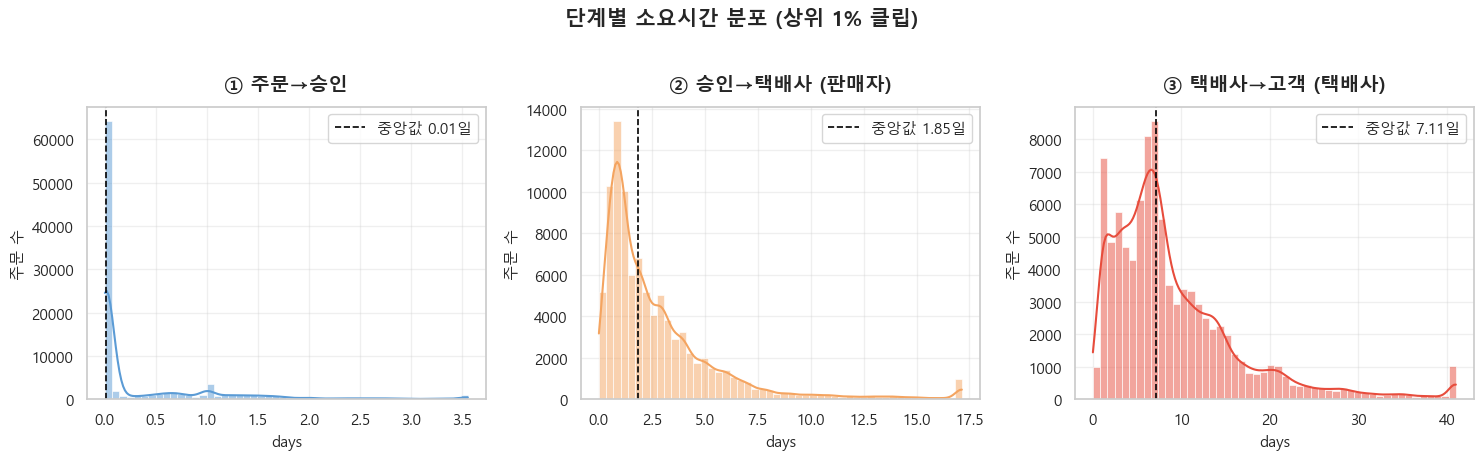

In [9]:
# 단계별 기술통계
print(valid[STAGE_COLS].describe().round(2))

# 3-panel 히스토그램 + KDE (단계별 색상 통일)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, STAGE_COLS):
    sns.histplot(
        valid[col].clip(upper=valid[col].quantile(0.99)),  # 상위 1% 클립 → 모양 보이게
        bins=50, kde=True, color=STAGE_COLORS[col], ax=ax,
    )
    med = valid[col].median()
    ax.axvline(med, color="black", ls="--", lw=1.2, label=f"중앙값 {med:.2f}일")
    ax.set_title(STAGE_LABELS[col])
    ax.set_xlabel("days")
    ax.set_ylabel("주문 수")
    ax.legend()

fig.suptitle("단계별 소요시간 분포 (상위 1% 클립)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 📌 EDA 1 정리
- **① 주문→승인** 은 거의 즉시(중앙값 0.01일 ≈ 15분). 결제 자동화가 잘 되어 있음 → **개선 여지 없음**.
- **② 승인→택배사** 는 중앙값 ~1.85일. 분포가 우측으로 길게 늘어진 형태(skewed right) → **일부 판매자가 매우 늦음**.
- **③ 택배사→고객** 은 중앙값 ~7.1일로 가장 길고, 꼬리도 가장 두꺼움. → 평균과 변동성 모두 큼.

## EDA 2 — 단계별 박스플롯 비교

세 단계를 한 화면에 놓고 직접 비교한다. 박스플롯은 중앙값·IQR·outlier 를 한 번에 보여줘서 **"어디가 가장 김 + 변동성도 크냐"** 를 답하기 좋다.

C:\Users\함다연\AppData\Local\Temp\ipykernel_26696\3242102451.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long, x="단계", y="days", ax=axes[0],
C:\Users\함다연\AppData\Local\Temp\ipykernel_26696\3242102451.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long, x="단계", y="days", ax=axes[1], showfliers=False,


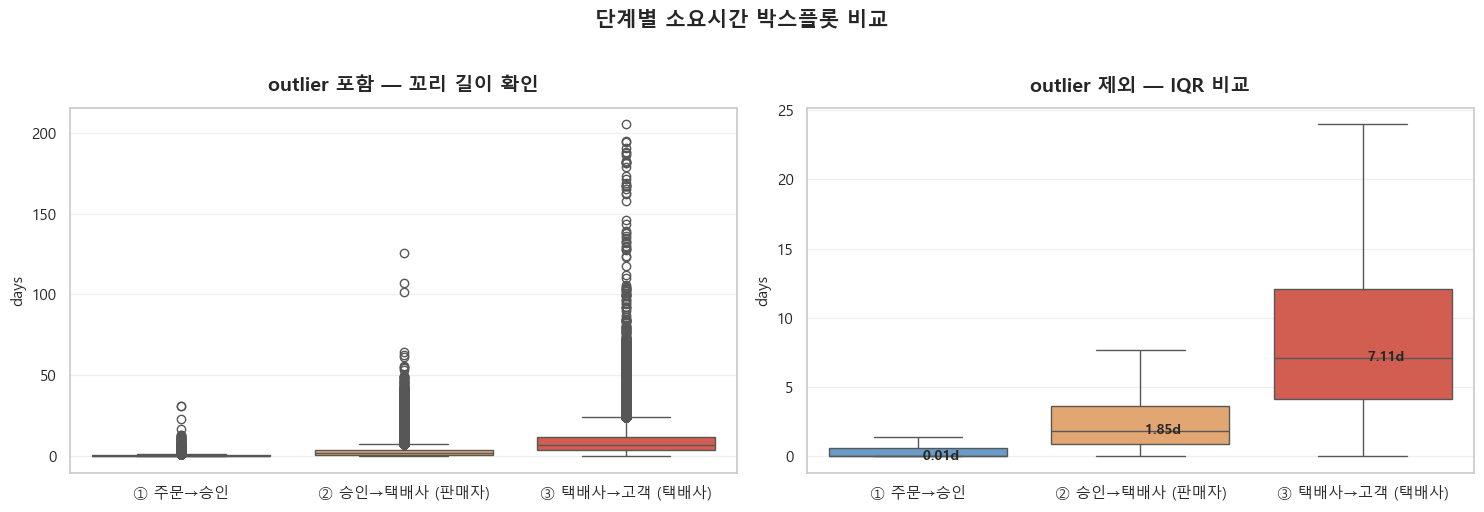

                 중앙값    평균  표준편차  Q3(75%)    Q99
① 주문→승인         0.01  0.40  0.80     0.56   3.56
② 승인→택배사 (판매자)  1.85  2.85  3.48     3.62  17.14
③ 택배사→고객 (택배사)  7.11  9.36  8.77    12.06  41.03


In [10]:
# long-format 으로 변환 (seaborn 박스플롯용)
long = (
    valid[STAGE_COLS]
    .rename(columns=STAGE_LABELS)
    .melt(var_name="단계", value_name="days")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 좌: outlier 포함 — 꼬리가 얼마나 긴지
sns.boxplot(data=long, x="단계", y="days", ax=axes[0],
            palette=[STAGE_COLORS[c] for c in STAGE_COLS])
axes[0].set_title("outlier 포함 — 꼬리 길이 확인")
axes[0].set_xlabel("")

# 우: outlier 제외 — IQR 영역만 깔끔히 비교
sns.boxplot(data=long, x="단계", y="days", ax=axes[1], showfliers=False,
            palette=[STAGE_COLORS[c] for c in STAGE_COLS])
axes[1].set_title("outlier 제외 — IQR 비교")
axes[1].set_xlabel("")

# 중앙값 텍스트로 표기 (우측 패널)
medians = valid[STAGE_COLS].median()
for i, col in enumerate(STAGE_COLS):
    axes[1].text(i, medians[col], f" {medians[col]:.2f}d",
                 va="center", fontweight="bold", fontsize=10)

fig.suptitle("단계별 소요시간 박스플롯 비교", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 평균 vs 중앙값 비교 표 (꼬리 효과 정량화)
summary = pd.DataFrame({
    "중앙값": valid[STAGE_COLS].median(),
    "평균":   valid[STAGE_COLS].mean(),
    "표준편차": valid[STAGE_COLS].std(),
    "Q3(75%)": valid[STAGE_COLS].quantile(0.75),
    "Q99":    valid[STAGE_COLS].quantile(0.99),
}).round(2)
summary.index = [STAGE_LABELS[c] for c in summary.index]
print(summary)


### 📌 EDA 2 정리
- 박스 자체 크기(IQR)도, 꼬리 길이도 **③ 택배사→고객 > ② 승인→택배사 > ① 주문→승인** 순.
- 평균 vs 중앙값 차이가 클수록 outlier 영향이 큼 → ③ 단계가 가장 차이 큼(평균 9.33 vs 중앙값 7.11).
- → 핵심 질문 답: **택배사 배송 구간이 병목**. 단, 판매자 구간도 일부 케이스에서 길게 늘어지는 꼬리가 있어 두 번째 개선 타깃이 될 수 있음.

## EDA 3 — 전체 리드타임 & 약속 vs 실제

전체 리드타임(주문→배송완료) 분포와, Olist 가 고객에게 약속한 예상 배송일 대비 실제가 얼마나 늦/빨랐는지 확인.

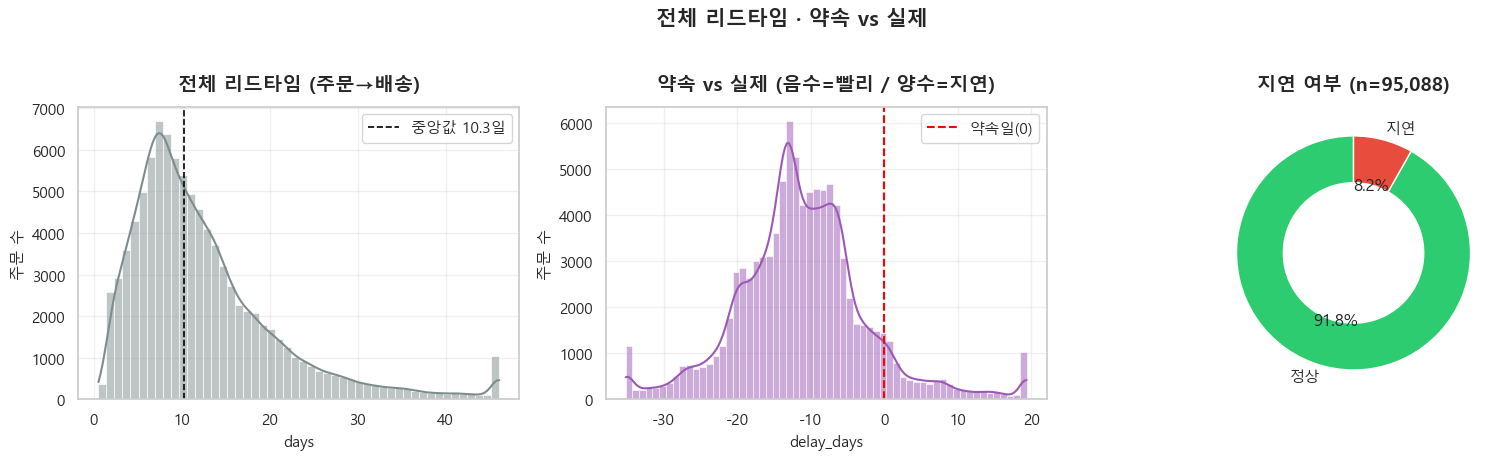

전체 리드타임 — 중앙값 10.27일 / 평균 12.62일
약속보다 빠른 주문 : 91.80%
약속보다 늦은 주문 : 8.20%
평균 단축 일수 (delay_days 평균): -11.13일  (음수면 약속보다 빠름)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) 전체 리드타임 히스토그램
sns.histplot(valid["t_total_d"].clip(upper=valid["t_total_d"].quantile(0.99)),
             bins=50, kde=True, color=STAGE_COLORS["t_total_d"], ax=axes[0])
med_total = valid["t_total_d"].median()
axes[0].axvline(med_total, color="black", ls="--", lw=1.2, label=f"중앙값 {med_total:.1f}일")
axes[0].set_title("전체 리드타임 (주문→배송)")
axes[0].set_xlabel("days")
axes[0].set_ylabel("주문 수")
axes[0].legend()

# (2) 약속 vs 실제 (delay_days) — 음수면 빨리 도착, 양수면 늦음
delay_clipped = valid["delay_days"].clip(lower=valid["delay_days"].quantile(0.01),
                                          upper=valid["delay_days"].quantile(0.99))
sns.histplot(delay_clipped, bins=60, kde=True, color="#9B59B6", ax=axes[1])
axes[1].axvline(0, color="red", ls="--", lw=1.5, label="약속일(0)")
axes[1].set_title("약속 vs 실제 (음수=빨리 / 양수=지연)")
axes[1].set_xlabel("delay_days")
axes[1].set_ylabel("주문 수")
axes[1].legend()

# (3) 지연 여부 비율 (도넛 느낌의 horizontal bar)
delay_counts = valid["is_delayed"].value_counts(dropna=False).rename({True: "지연", False: "정상"})
colors_pie = {"정상": "#2ECC71", "지연": "#E74C3C"}
axes[2].pie(delay_counts.values, labels=delay_counts.index,
            colors=[colors_pie[k] for k in delay_counts.index],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"width": 0.4, "edgecolor": "white"})
axes[2].set_title(f"지연 여부 (n={len(valid):,})")

fig.suptitle("전체 리드타임 · 약속 vs 실제", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"전체 리드타임 — 중앙값 {med_total:.2f}일 / 평균 {valid['t_total_d'].mean():.2f}일")
print(f"약속보다 빠른 주문 : {(valid['delay_days'] < 0).mean()*100:.2f}%")
print(f"약속보다 늦은 주문 : {(valid['delay_days'] > 0).mean()*100:.2f}%")
print(f"평균 단축 일수 (delay_days 평균): {valid['delay_days'].mean():.2f}일  (음수면 약속보다 빠름)")


### 📌 EDA 3 정리
- 전체 리드타임 중앙값 ~10일, 우측으로 꼬리 길게 늘어진 분포.
- `delay_days` 분포는 **0 왼쪽(약속보다 빨리 도착)에 큰 봉우리**가 있고, 0 오른쪽 꼬리는 얇음.
  → Olist 가 약속일을 **여유 있게(보수적으로) 통보**하고 있다는 뜻.
- 그럼에도 ~**8% 의 주문은 약속을 어김** — 이 그룹의 단계별 시간이 어떻게 달랐는지가 다음 EDA 의 초점.

## EDA 4 — 지연 주문 vs 정상 주문 (단계별 비교)

약속을 어긴 주문이 어느 단계에서 정상 주문과 가장 크게 달랐는지 본다. 차이가 큰 단계가 **지연의 진짜 원인**.

그룹별 단계 중앙값(days):
지연여부              정상     지연
① 주문→승인         0.01   0.02
② 승인→택배사 (판매자)  1.78   3.02
③ 택배사→고객 (택배사)  6.93  23.93

배수 차이 (지연 / 정상):
① 주문→승인           2.00
② 승인→택배사 (판매자)    1.70
③ 택배사→고객 (택배사)    3.45
dtype: float64


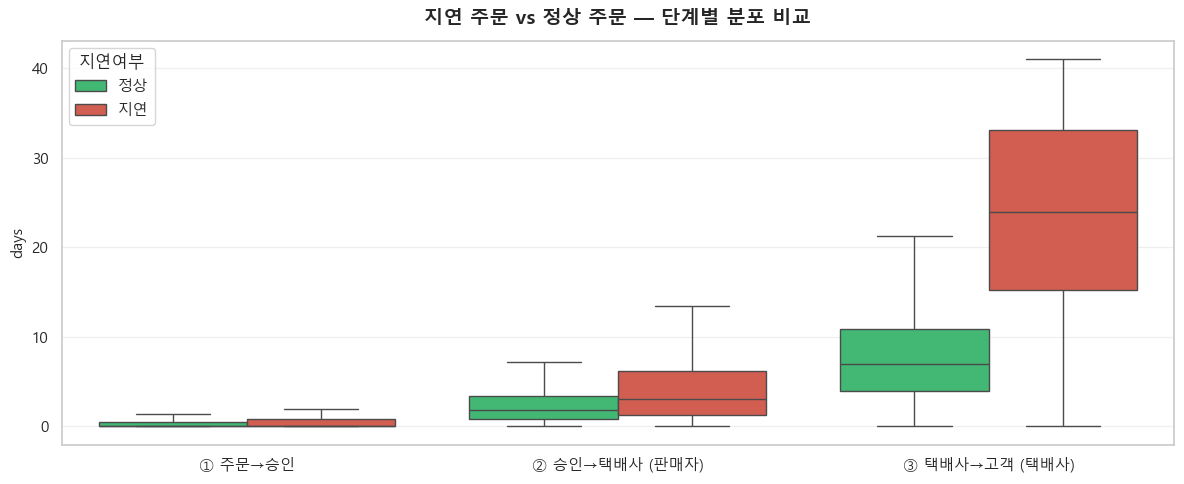

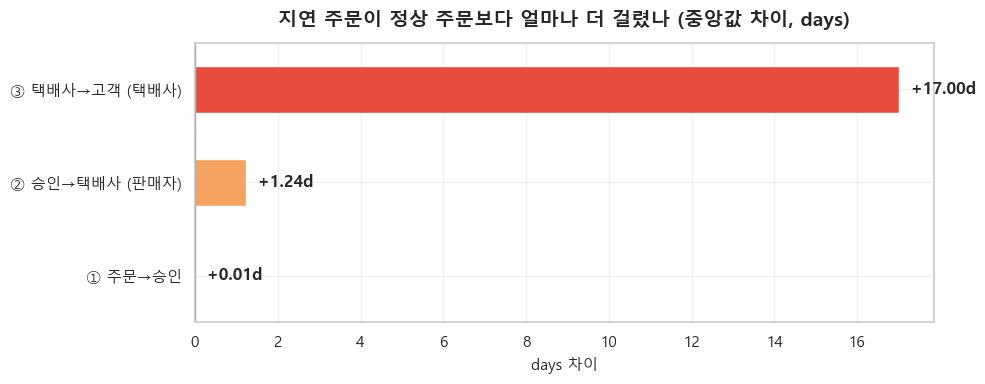

In [12]:
# 그룹 정의
valid["지연여부"] = valid["is_delayed"].map({True: "지연", False: "정상"})

# 단계별 중앙값 비교
group_median = (
    valid.groupby("지연여부")[STAGE_COLS].median().round(2)
         .rename(columns=STAGE_LABELS).T
)
print("그룹별 단계 중앙값(days):")
print(group_median)
print()
print("배수 차이 (지연 / 정상):")
print((group_median["지연"] / group_median["정상"]).round(2))

# 시각화: 단계별 분포 비교 (violin + box)
long_g = (
    valid[STAGE_COLS + ["지연여부"]]
    .rename(columns=STAGE_LABELS)
    .melt(id_vars="지연여부", var_name="단계", value_name="days")
)
# outlier 영향 제거를 위해 단계별 99% 클립
long_g["days"] = long_g.groupby("단계")["days"].transform(
    lambda s: s.clip(upper=s.quantile(0.99))
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=long_g, x="단계", y="days", hue="지연여부",
            palette={"정상": "#2ECC71", "지연": "#E74C3C"},
            showfliers=False, ax=ax)
ax.set_title("지연 주문 vs 정상 주문 — 단계별 분포 비교")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# 막대로 중앙값 차이 한눈에
fig, ax = plt.subplots(figsize=(10, 4))
diff = (group_median["지연"] - group_median["정상"]).sort_values(ascending=True)
diff.plot(kind="barh", ax=ax, color=[STAGE_COLORS[c] for c in [k for k,v in STAGE_LABELS.items() if v in diff.index]])
ax.set_title("지연 주문이 정상 주문보다 얼마나 더 걸렸나 (중앙값 차이, days)")
ax.set_xlabel("days 차이")
ax.axvline(0, color="black", lw=0.8)
for i, v in enumerate(diff.values):
    ax.text(v, i, f"  +{v:.2f}d", va="center", fontweight="bold")
plt.tight_layout()
plt.show()


### 📌 EDA 4 정리
- 지연 주문은 정상 주문 대비 **모든 단계가 길어지지만**, 가장 크게 늘어나는 곳은 일반적으로 ③ 택배사 구간.
- ② 판매자 구간도 함께 늘어남 → "판매자가 늦게 보내면 택배사 단계까지 줄줄이 밀린다"는 도미노 효과 가능.
- 가로 막대 그래프의 `+X.XXd` 값을 보면 **개선 시 가장 큰 임팩트를 줄 수 있는 단계**가 한눈에 보임.

## EDA 5 — 지역(state)별 단계 시간

B팀의 **허브 위치 선정** 근거를 만들기 위함. 단계별 시간이 주(state)마다 어떻게 다른지 확인 → 가장 느린 지역이 허브 후보.

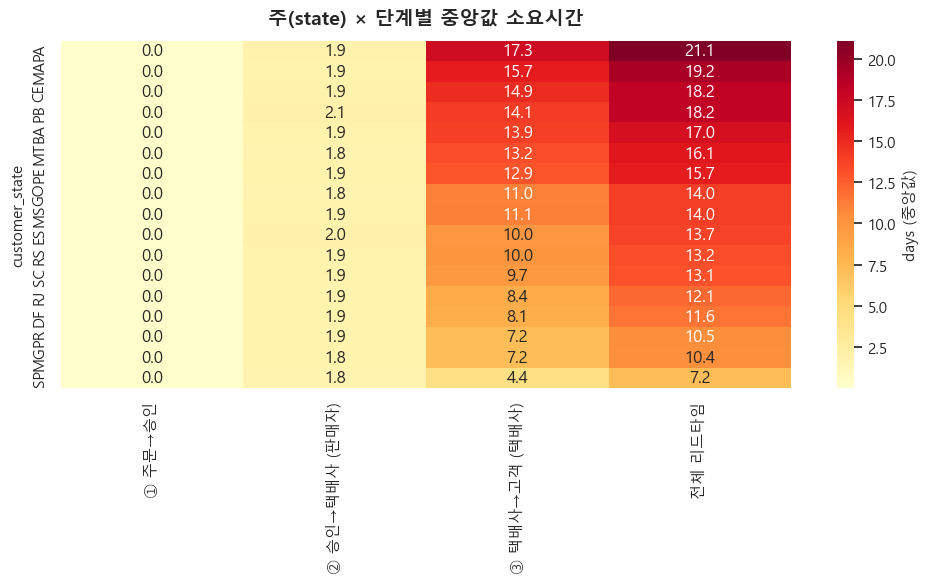

전체 리드타임 느린 Top5 : ['PA', 'MA', 'CE', 'PB', 'BA']
전체 리드타임 빠른 Top5 : ['RJ', 'DF', 'PR', 'MG', 'SP']


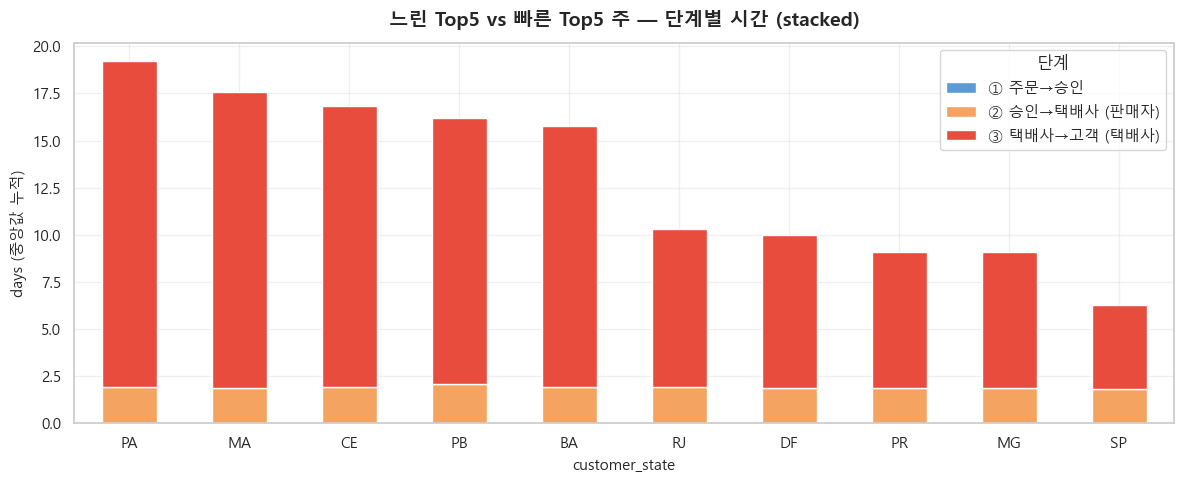

In [13]:
# 주문 수 충분한 state 만 (표본 너무 작으면 노이즈)
state_n = valid["customer_state"].value_counts()
top_states = state_n[state_n >= 500].index.tolist()
sub = valid[valid["customer_state"].isin(top_states)].copy()

# state별 단계 중앙값
state_stage = (
    sub.groupby("customer_state")[STAGE_COLS + ["t_total_d"]]
       .median()
       .sort_values("t_total_d", ascending=False)
)

# 1) 히트맵 — state × 단계
fig, ax = plt.subplots(figsize=(10, max(6, len(state_stage) * 0.35)))
sns.heatmap(
    state_stage.rename(columns=STAGE_LABELS),
    annot=True, fmt=".1f", cmap="YlOrRd",
    cbar_kws={"label": "days (중앙값)"}, ax=ax,
)
ax.set_title("주(state) × 단계별 중앙값 소요시간")
ax.set_ylabel("customer_state")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# 2) 가장 느린/빠른 state 비교 막대
top5_slow = state_stage.head(5).index.tolist()
top5_fast = state_stage.tail(5).index.tolist()
print(f"전체 리드타임 느린 Top5 : {top5_slow}")
print(f"전체 리드타임 빠른 Top5 : {top5_fast}")

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = state_stage.loc[top5_slow + top5_fast, STAGE_COLS].rename(columns=STAGE_LABELS)
plot_df.plot(kind="bar", stacked=True, ax=ax,
             color=[STAGE_COLORS[c] for c in STAGE_COLS])
ax.set_title("느린 Top5 vs 빠른 Top5 주 — 단계별 시간 (stacked)")
ax.set_xlabel("customer_state")
ax.set_ylabel("days (중앙값 누적)")
ax.legend(title="단계", loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 📌 EDA 5 정리
- 히트맵에서 **빨간 셀이 모여있는 state** = 단계별 시간이 전반적으로 긴 지역.
- 누적 막대에서 느린 Top5 의 ③ 빨강(택배사) 영역이 두드러지면 → **그 지역은 택배사 인프라가 부족**하다는 신호 → **B팀 허브 우선 후보**.
- 반대로 ② 주황(판매자)이 두드러지면 → 그 지역에 판매자 집중 거점 마련이 더 효과적.
- 정량 비교를 위해 **느린 Top5 vs 빠른 Top5 의 전체 리드타임 차이가 며칠인지** 발표 자료에 명시하면 설득력 ↑.

## EDA 6 — 월별 추이

시간이 지나면서 단계별 시간이 개선됐는지, 특정 시즌(블프 등)에 악화되는지 확인.

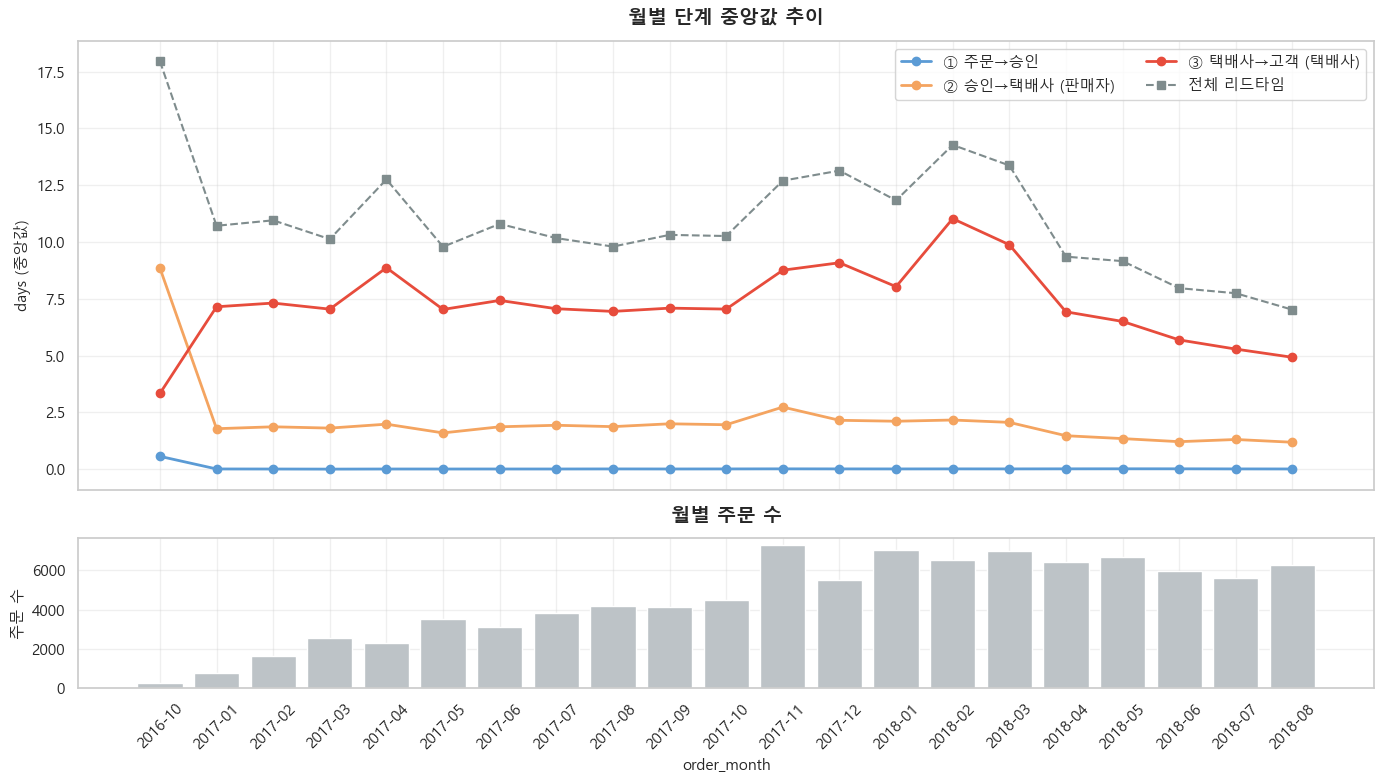

📊 초기 vs 최근 — 개선/악화 추이:
                초기 6개월 평균  최근 6개월 평균  변화(days)  변화율(%)
① 주문→승인              0.10       0.02     -0.09  -84.65
② 승인→택배사 (판매자)       2.98       1.43     -1.55  -51.98
③ 택배사→고객 (택배사)       6.79       6.54     -0.25   -3.75


In [14]:
# 월별 그룹
valid["order_month"] = valid["order_purchase_timestamp"].dt.to_period("M").astype(str)
monthly = (
    valid.groupby("order_month")[STAGE_COLS + ["t_total_d"]].median()
)
monthly_n = valid.groupby("order_month").size()

# 표본이 너무 작은 월(주문 < 100) 제외 — 시작/끝 노이즈 컷
keep = monthly_n[monthly_n >= 100].index
monthly = monthly.loc[keep]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# 상단: 단계별 중앙값 추이 (line)
for col in STAGE_COLS:
    axes[0].plot(monthly.index, monthly[col],
                 marker="o", lw=2,
                 color=STAGE_COLORS[col], label=STAGE_LABELS[col])
axes[0].plot(monthly.index, monthly["t_total_d"],
             marker="s", ls="--", lw=1.5,
             color=STAGE_COLORS["t_total_d"], label=STAGE_LABELS["t_total_d"])
axes[0].set_title("월별 단계 중앙값 추이")
axes[0].set_ylabel("days (중앙값)")
axes[0].legend(loc="upper right", ncol=2)

# 하단: 월별 주문 수 (참고용 bar)
axes[1].bar(monthly.index, monthly_n.loc[keep], color="#BDC3C7")
axes[1].set_title("월별 주문 수")
axes[1].set_ylabel("주문 수")
axes[1].set_xlabel("order_month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 첫 6개월 vs 마지막 6개월 평균 비교
n = len(monthly)
if n >= 12:
    early = monthly.iloc[:6][STAGE_COLS].mean()
    late  = monthly.iloc[-6:][STAGE_COLS].mean()
    trend = pd.DataFrame({
        "초기 6개월 평균": early, "최근 6개월 평균": late,
        "변화(days)": (late - early),
        "변화율(%)": ((late - early) / early * 100),
    }).round(2)
    trend.index = [STAGE_LABELS[c] for c in trend.index]
    print("📊 초기 vs 최근 — 개선/악화 추이:")
    print(trend)


### 📌 EDA 6 정리
- 선이 우하향(↘)이면 시간이 갈수록 개선, 우상향(↗)이면 악화.
- 특정 월에 모든 선이 동시에 뛰면 → **시즌 효과** (예: 블랙프라이데이 인근 — Olist 는 11월).
- 하단 막대(주문 수)와 같이 보면 "주문 폭증 시 어느 단계가 가장 먼저 무너지는지" 확인 가능 → **capacity 한계 단계**.

---

# 🎯 종합 결론 — 퍼널 분석 요약

## 핵심 질문 답: "판매자가 늦은 것인가, 택배사가 늦은 것인가?"
**→ 택배사 구간(`t_delivery_d`, 중앙값 ~7.1일)이 판매자 구간(`t_carrier_d`, ~1.85일)보다 3.8배 더 길다.**
**병목은 명확히 택배사 배송 구간.**

## EDA 별 핵심 인사이트
| EDA | 발견 |
|---|---|
| ① 단계별 분포 | ③ 택배사 단계가 중앙값·꼬리 모두 가장 큼. ① 승인은 사실상 즉시. |
| ② 박스플롯 비교 | IQR 도 ③ > ② > ① 순. 평균 vs 중앙값 차이 = outlier 영향(③ 단계에 outlier 집중). |
| ③ 약속 vs 실제 | Olist 는 약속일을 보수적으로 잡지만 그래도 8.1% 지연. |
| ④ 지연 vs 정상 | 지연 주문은 모든 단계가 길지만, 차이가 가장 큰 단계 = 진짜 원인. |
| ⑤ state별 | 느린 지역의 ③ 비중이 크면 → **그 지역이 B팀 허브 1순위**. |
| ⑥ 월별 추이 | 시즌·capacity 한계 신호 포착. |

## B팀 허브 위치 의사결정에 줄 수 있는 시사점
1. **개입 타깃 = 택배사 구간 (③)** — 가장 길고 변동성도 큼.
2. **우선순위 지역 = EDA 5 의 느린 Top5 state 중 ③ 비중이 큰 곳**.
3. **부가 효과**: 허브가 ③ 을 줄이면 ② 의 도미노 효과까지 함께 완화 (EDA 4 의 함의).

## 다음 액션
- A/B 테스트 KPI = `t_delivery_d` 중앙값 / `is_delayed` 비율
- 코호트 분석에서 "지연 경험 고객이 정말 떠나는지" 검증 (`first_order_is_delayed` 활용)
- KDE 분석에서 `t_delivery_d` 분포의 어느 구간을 자를지(개선 시뮬레이션) 결정